In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model='llama-3.1-8b-instant')

In [4]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

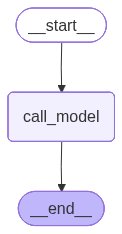

In [6]:
graph = builder.compile()
graph

In [7]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Nitish."}]})

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='e579520e-a72f-4043-93f5-bc8108253371'),
  AIMessage(content="Hello Nitish, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 43, 'total_tokens': 70, 'completion_time': 0.023826635, 'completion_tokens_details': None, 'prompt_time': 0.002543668, 'prompt_tokens_details': None, 'queue_time': 0.051203462, 'total_time': 0.026370303}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dc90b-b734-7d92-b625-c6aa85cb53c9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 27, 'total_tokens': 70})]}

In [8]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='f12f280d-2ace-4a13-b370-0bf9ecce4811'),
  AIMessage(content="I don't have any information about your name. I'm a large language model, I don't have the ability to retain information about individual users or their personal details. Each time you interact with me, it's a new conversation and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 40, 'total_tokens': 116, 'completion_time': 0.074245529, 'completion_tokens_details': None, 'prompt_time': 0.002789073, 'prompt_tokens_details': None, 'queue_time': 0.051760916, 'total_time': 0.077034602}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--0

### above without memory , below is with memory

In [9]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [10]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver() # store in RAM
graph = builder.compile(checkpointer=checkpointer)

In [12]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [13]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Nitish."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='8e18c4ef-e2f3-43d0-bd52-ab3766b23367'),
  AIMessage(content="Hello Nitish, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 43, 'total_tokens': 70, 'completion_time': 0.023912204, 'completion_tokens_details': None, 'prompt_time': 0.002348372, 'prompt_tokens_details': None, 'queue_time': 0.050439468, 'total_time': 0.026260576}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dc90c-bada-73a3-9e21-90b8b6ed3341-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 27, 'total_tokens': 70})]}

In [14]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config2)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='b452b9e6-ac6d-4375-a134-1f58e87b7c8c'),
  AIMessage(content="I don't have information about your name. I'm a large language model, I don't have the ability to retain personal information or remember past conversations. Each time you interact with me, it's a new conversation. If you'd like to share your name with me, I can use it in our conversation. Alternatively, I can refer to you by a pseudonym or a nickname if you prefer.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 40, 'total_tokens': 122, 'completion_time': 0.102554826, 'completion_tokens_details': None, 'prompt_time': 0.001870861, 'prompt_tokens_details': None, 'queue_time': 0.050720124, 'total_time': 0.104425687}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_prov

In [18]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='8e18c4ef-e2f3-43d0-bd52-ab3766b23367'),
  AIMessage(content="Hello Nitish, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 43, 'total_tokens': 70, 'completion_time': 0.023912204, 'completion_tokens_details': None, 'prompt_time': 0.002348372, 'prompt_tokens_details': None, 'queue_time': 0.050439468, 'total_time': 0.026260576}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dc90c-bada-73a3-9e21-90b8b6ed3341-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 27, 'total_tokens': 70}),
  HumanMessage(content='What is my name?', additional_kwargs={}, response_m

In [19]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Nitish.
- AIMessage : Hello Nitish, it's nice to meet you. Is there something I can help you with or would you like to chat?
- HumanMessage : What is my name?
- AIMessage : Your name is Nitish.
